# 02 — Signal Assessment & Data Forensics

**Context:** this project began as a revenue analysis but pivoted to a **Forensic Data Audit** after early exploration revealed strong indicators of synthetic generation. Full rationale: [`reports/00_business_problem.md`](../reports/00_business_problem.md).

**Goal of this notebook:** test whether the dataset contains genuine business signal or artificial noise, by examining four audit hypotheses with SQL aggregations and statistical tests.

**Hypotheses tested here:**
1. **Channel performance** — do booking channels differ financially?
2. **Seasonality** — is there natural seasonal variation across the year?
3. **Customer segmentation** — do customer types differ in behaviour / purchasing power?
4. **Natural variance** — do financial metrics follow natural (skewed) distributions, or an artificial (uniform) spread?

**Methods:** DuckDB grouping queries · Chi-Square independence tests · distribution fingerprinting (histograms, correlation matrix). Key charts exported to `visuals/`.

**Kontekst**: projekt rozpoczął się jako analiza przychodów, ale został przekształcony w forensic data audit, po tym jak wstępna eksploracja ujawniła silne przesłanki generowania syntetycznych danych. Pełne uzasadnienie znajduje się w: reports/00_business_problem.md.

**Cel notebooka**: sprawdzenie, czy zbiór danych zawiera rzeczywisty sygnał biznesowy, czy sztuczny szum, poprzez analizę czterech hipotez audytowych z wykorzystaniem agregacji SQL i testów statystycznych.

**Hipotezy testowane w tym notebooku:**

1. **Wydajność kanałów** — czy kanały rezerwacji różnią się pod względem finansowym?
2. **Sezonowość** — czy występują naturalne wahania sezonowe w ciągu roku?
3. **Segmentacja klientów** — czy typy klientów różnią się zachowaniem i poziomem wydatków?
4. **Naturalna zmienność** — czy metryki finansowe mają naturalny (skośny) rozkład, czy sztuczny (jednorodny) rozkład?

**Metody:** zapytania grupujące DuckDB · testy niezależności Chi-kwadrat · fingerprinting rozkładów (histogramy, macierz korelacji). Kluczowe wykresy zapisano w folderze visuals/.

In [74]:
import duckdb
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [75]:
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
parquet_path = PROJECT_ROOT / 'data' / 'processed' / 'hotels_clean.parquet'

visuals_dir = PROJECT_ROOT / 'visuals'
visuals_dir.mkdir(exist_ok=True) 

conn = duckdb.connect(database=':memory:')
conn.execute(f"CREATE OR REPLACE VIEW bookings AS SELECT * FROM '{parquet_path}'")

query = """
SELECT * FROM bookings 
LIMIT 5;
"""

df_preview = conn.execute(query).df()
display(df_preview)

,Booking_ID,Hotel_Name,Hotel_Category,City,State,Country,Month,Quarter,Year,Room_Type,...,Booking_Channel,Customer_Type,Payment_Mode,Occupancy_Status,Customer_Rating,Feedback_Status,Covid_Impact_Level,Checkin_Date,Checkout_Date,nights_calc
0,BK9835534,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,May,Q2,2021,Deluxe,...,Walk-in,Regular,UPI,Checked-Out,4.6,Positive,High,2021-05-04,2021-05-08,4
1,BK7803377,ITC Royal Bengal,Luxury,Kolkata,West Bengal,India,June,Q2,2021,Presidential Suite,...,Corporate,VIP,Credit Card,Checked-In,4.6,Positive,High,2021-06-05,2021-06-09,4
2,BK3686278,ITC Grand Goa,Resort,Goa,Goa,India,September,Q3,2021,Luxury Suite,...,Booking.com,Corporate,Cash,Checked-In,4.2,Positive,Low,2021-09-04,2021-09-06,2
3,BK7514886,Fortune Select Trinity,Business,Bengaluru,Karnataka,India,September,Q3,2021,Executive,...,Website,Regular,Debit Card,Cancelled,3.8,Neutral,Low,2021-09-30,2021-10-01,1
4,BK6312815,ITC Narmada,Business,Ahmedabad,Gujarat,India,September,Q3,2021,Deluxe,...,Walk-in,New Guest,UPI,Checked-In,4.6,Negative,Low,2021-09-22,2021-09-24,2


In [76]:
query = """
SUMMARIZE bookings;
"""

df_rooms = conn.execute(query).df()
display(df_rooms)

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,Booking_ID,VARCHAR,BK1000044,BK9999990,237035,NaN,NaN,NaN,NaN,NaN,299998,0.0
1,Hotel_Name,VARCHAR,Fortune Select Trinity,Welcomhotel Dwarka,15,NaN,NaN,NaN,NaN,NaN,299998,0.0
2,Hotel_Category,VARCHAR,Business,Resort,3,NaN,NaN,NaN,NaN,NaN,299998,0.0
3,City,VARCHAR,Agra,New Delhi,11,NaN,NaN,NaN,NaN,NaN,299998,0.0
4,State,VARCHAR,Delhi,West Bengal,9,NaN,NaN,NaN,NaN,NaN,299998,0.0
5,Country,VARCHAR,India,India,1,NaN,NaN,NaN,NaN,NaN,299998,0.0
6,Month,VARCHAR,April,September,12,NaN,NaN,NaN,NaN,NaN,299998,0.0
7,Quarter,VARCHAR,Q1,Q4,4,NaN,NaN,NaN,NaN,NaN,299998,0.0
8,Year,BIGINT,2021,2022,2,2021.245204968033,0.4302093776555841,2021,2021,2021,299998,0.0
9,Room_Type,VARCHAR,Club Room,Presidential Suite,5,NaN,NaN,NaN,NaN,NaN,299998,0.0


In [77]:
query = """
SELECT 
    Hotel_Name, 
    SUM(Net_Revenue) AS Total_Net_Revenue, 
    SUM(Gross_Revenue) AS Total_Gross_Revenue, 
    SUM(Net_Revenue) / CAST(SUM(Gross_Revenue) AS DOUBLE) AS Margin_prc, 
    COUNT(*) AS Total_Bookings
FROM bookings
GROUP BY Hotel_Name
ORDER BY Total_Net_Revenue DESC;
"""

df_hotels = conn.execute(query).df()
display(df_hotels)

,Hotel_Name,Total_Net_Revenue,Total_Gross_Revenue,Margin_prc,Total_Bookings
0,ITC Mughal,1.013674e+09,1.064302e+09,0.952431,20279
1,ITC Maratha,1.006410e+09,1.056827e+09,0.952293,20139
2,ITC Kakatiya,1.004672e+09,1.054612e+09,0.952646,20092
3,Welcomhotel Dwarka,1.001034e+09,1.050968e+09,0.952488,19977
4,ITC Maurya,9.958203e+08,1.045836e+09,0.952176,20047
5,ITC Rajputana,9.950206e+08,1.045385e+09,0.951823,20087
6,ITC Grand Chola,9.937587e+08,1.043962e+09,0.951911,20049
7,ITC Royal Bengal,9.905442e+08,1.040297e+09,0.952175,19925
8,ITC Sonar,9.902254e+08,1.039623e+09,0.952485,19843
9,ITC Grand Goa,9.898101e+08,1.039977e+09,0.951762,20143


In [78]:
query = """
SELECT Booking_Channel, 
    SUM(Net_Revenue) AS Total_Net_Revenue, 
    SUM(Gross_Revenue) AS Total_Gross_Revenue, 
    SUM(Net_Revenue) / CAST(SUM(Gross_Revenue) AS DOUBLE) AS Margin_prc, 
    COUNT(*) AS Total_Bookings
FROM bookings
GROUP BY Booking_Channel;
"""

df_booking_channels = conn.execute(query).df()
display(df_booking_channels)

,Booking_Channel,Total_Net_Revenue,Total_Gross_Revenue,Margin_prc,Total_Bookings
0,Walk-in,2.461705e+09,2.585907e+09,0.951970,49666
1,Booking.com,2.484228e+09,2.609627e+09,0.951948,50117
2,Website,2.493411e+09,2.618224e+09,0.952329,49959
3,Goibibo,2.480323e+09,2.604898e+09,0.952177,49972
4,MakeMyTrip,2.498514e+09,2.623976e+09,0.952187,50158
5,Corporate,2.496651e+09,2.622315e+09,0.952079,50126


In [79]:
query = """
SELECT Customer_Type, 
    SUM(Net_Revenue) AS Total_Net_Revenue, 
    SUM(Gross_Revenue) AS Total_Gross_Revenue, 
    SUM(Net_Revenue) / CAST(SUM(Gross_Revenue) AS DOUBLE) AS Margin_prc, 
    COUNT(*) AS Total_Bookings
FROM bookings
GROUP BY Customer_Type;
"""

df_customer_types = conn.execute(query).df()
display(df_customer_types)

,Customer_Type,Total_Net_Revenue,Total_Gross_Revenue,Margin_prc,Total_Bookings
0,VIP,2.967691e+09,3.118020e+09,0.951787,59916
1,Corporate,3.005455e+09,3.155540e+09,0.952438,60258
2,New Guest,2.995132e+09,3.145560e+09,0.952178,60155
3,Member,2.982358e+09,3.132729e+09,0.952000,60058
4,Regular,2.964196e+09,3.113096e+09,0.952170,59611


In [80]:
query = """
SELECT Covid_Impact_Level, 
    SUM(Net_Revenue) AS Total_Net_Revenue, 
    SUM(Gross_Revenue) AS Total_Gross_Revenue, 
    SUM(Net_Revenue) / CAST(SUM(Gross_Revenue) AS DOUBLE) AS Margin_prc, 
    COUNT(*) AS Total_Bookings
FROM bookings
GROUP BY Covid_Impact_Level;
"""

df_covid_impact = conn.execute(query).df()
display(df_covid_impact)

,Covid_Impact_Level,Total_Net_Revenue,Total_Gross_Revenue,Margin_prc,Total_Bookings
0,High,5.011748e+09,5.262824e+09,0.952293,100599
1,Low,9.903084e+09,1.040212e+10,0.952026,199399


In [81]:
query_cancellations = """
SELECT 
    Booking_Channel,
    Customer_Type,
    COUNT(*) AS Total_Bookings,
    SUM(CASE WHEN Occupancy_Status = 'Cancelled' THEN 1 ELSE 0 END) AS Cancelled_Bookings,
    AVG(CASE WHEN Occupancy_Status = 'Cancelled' THEN 1.0 ELSE 0.0 END) AS Cancellation_Rate
FROM bookings
GROUP BY 
    Booking_Channel, 
    Customer_Type
ORDER BY 
    Cancellation_Rate DESC;
"""

df_cancellations = conn.execute(query_cancellations).df()
display(df_cancellations)

,Booking_Channel,Customer_Type,Total_Bookings,Cancelled_Bookings,Cancellation_Rate
0,Walk-in,Corporate,10074,1054.0,0.104626
1,MakeMyTrip,Regular,9948,1039.0,0.104443
2,Walk-in,VIP,9880,1028.0,0.104049
3,MakeMyTrip,New Guest,10085,1038.0,0.102925
4,Website,Regular,9928,1016.0,0.102337
5,Booking.com,Corporate,10013,1023.0,0.102167
6,Website,VIP,9927,1011.0,0.101843
7,Corporate,Corporate,10007,1019.0,0.101829
8,Website,Corporate,9889,1003.0,0.101426
9,Booking.com,Regular,10016,1002.0,0.100040


In [82]:
query_monthly_trends = """
SELECT 
    strftime(Checkin_Date, '%Y-%m') AS Year_Month,
    COUNT(*) AS Total_Bookings,
    SUM(Net_Revenue) AS Total_Net_Revenue,
    SUM(Gross_Revenue) AS Total_Gross_Revenue
FROM bookings
GROUP BY 
    Year_Month
ORDER BY 
    Year_Month ASC;
"""

df_monthly_trends = conn.execute(query_monthly_trends).df()
display(df_monthly_trends)

,Year_Month,Total_Bookings,Total_Net_Revenue,Total_Gross_Revenue
0,2021-04,24831,1.230749e+09,1.292617e+09
1,2021-05,25595,1.283535e+09,1.347640e+09
2,2021-06,24567,1.226947e+09,1.287885e+09
3,2021-07,25476,1.262751e+09,1.326558e+09
4,2021-08,25340,1.263440e+09,1.326833e+09
5,2021-09,24677,1.221443e+09,1.283028e+09
6,2021-10,25841,1.283193e+09,1.347863e+09
7,2021-11,24576,1.218880e+09,1.280521e+09
8,2021-12,25534,1.268007e+09,1.331552e+09
9,2022-01,25606,1.270517e+09,1.334682e+09


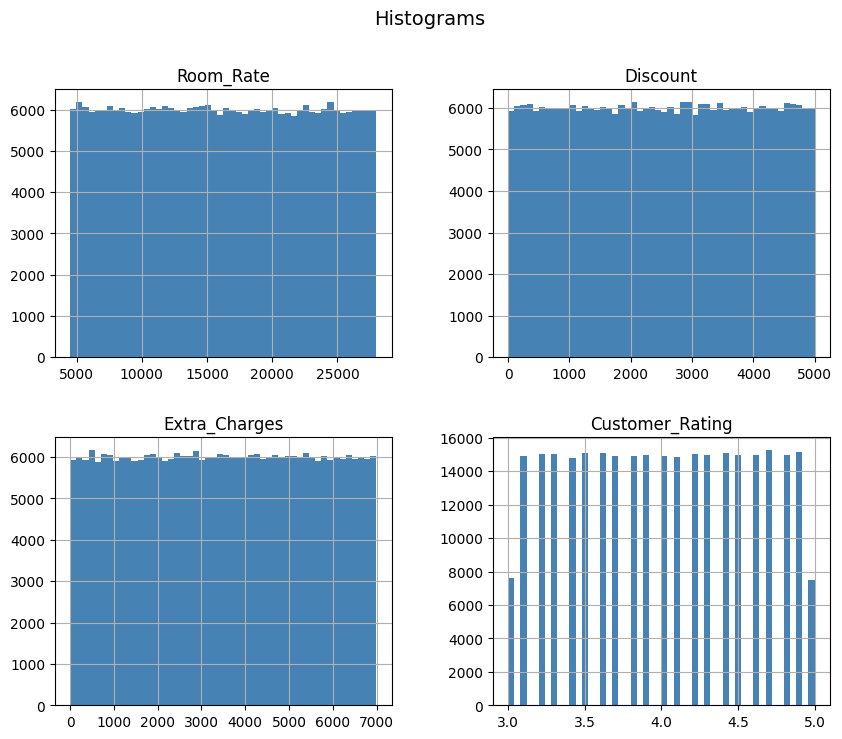

In [83]:
df = conn.execute("SELECT * FROM bookings").df()

cols_to_plot = ['Room_Rate', 'Discount', 'Extra_Charges', 'Customer_Rating']

# Pandas sam stworzy siatkę dla podanych kolumn
df[cols_to_plot].hist(bins=50, figsize=(10, 8), color='steelblue')
plt.suptitle('Histograms', fontsize=14)
plt.savefig(visuals_dir / '01_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### 🛑 Verdict: Hypothesis 4 (Natural Variance)

**Result: REJECTED.**

`Room_Rate`, `Discount`, and `Extra_Charges` follow a strict uniform distribution — every value is equally likely to appear across the entire defined range. 

In real-world business operations, financial metrics like prices, fees, and discounts are inherently right-skewed (a high volume of standard/lower prices with a long tail of expensive outliers). Perfect mathematical uniformity across 300,000 rows is a definitive signature of a uniform random generator (e.g., `numpy.random.uniform`). The data exhibits an artificial, non-organic spread, proving these columns were generated rather than observed.